# Ordinary Differential Equation Using Python 
# 1. Original Model 
\begin{equation}
\frac{d^2x}{dt^2} = -\omega ^2 x - \gamma \frac{dx}{dt} + \frac{e}{m} \sqrt{\frac{h\omega}{\epsilon _0}} \cos (\omega t + \theta)
\end{equation}
\begin{equation}
\gamma = \tau \cdot \omega ^2
\end{equation}
Neural cluster\begin{equation}
 0 < \eta < 2\pi
\end{equation}


### Reduced in a system of first order differential equations

Let 
\begin{cases}
x_1 = x \\
x_2 = \frac{dx}{dt}
\end{cases}
$\Rightarrow$
\begin{cases}
x_1' = \frac{dx}{dt} = x_2 \\
x_2' = \frac{d^2x}{dt^2} =  -\omega ^2 x - \gamma \frac{dx}{dt} + \frac{e}{m} \sqrt{\frac{h\omega}{\epsilon _0}} \cos (\omega t + \theta)
\end{cases}

Let us suppose that we have initial values: $x(t=0)=x_0$ and $x'(t=0) = x_0'$. Using the new variables, we obtain:
\begin{cases}
x_1(t=0) = x_0 \\
x_2(t=0) = x_0'
\end{cases}



In [2]:
# Libraries 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [87]:
# Parameters
w = 0.5
G = 0.5
e = 1.759 * 10**11
m = 1
h = 6.626 * 10**(-34) / (2*np.pi)   # ħ
V = 100
Eo = 8.85 * 10**(-12)
O = np.random.uniform(0, 2*np.pi)

# Definition of differential Equation 

def f(t, x):
    x1, x2 = x      
    dx1dt = x2
    dx2dt = -w**2 *x1 - G* x2 + (e/m)* np.sqrt((h*w)/(Eo * V))* np.cos(w*t + O)
    return [dx1dt, dx2dt]    

C:\Users\julio\AppData\Local\Temp\ipykernel_27892\3297482929.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


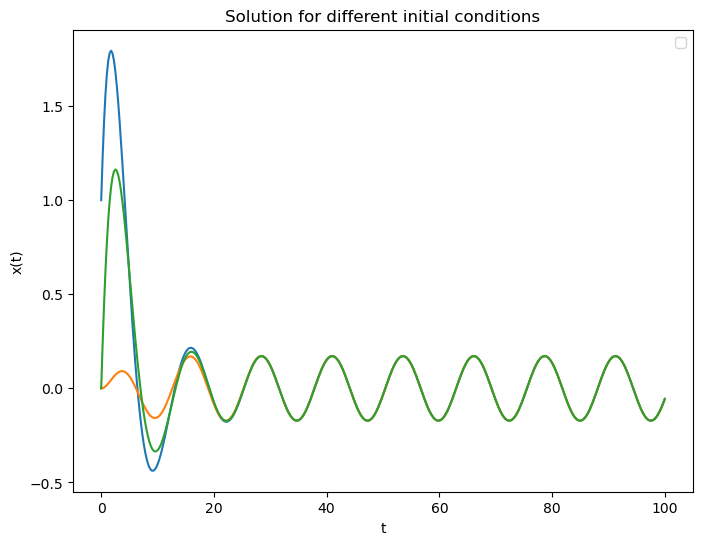

In [88]:
t_eval = np.linspace(0, 100, 400) # The value of t


#Initial Conditions 
Initial_condition = [[1, 1], [0, 0], [0, 1]]

plt.figure(figsize=(8,6))
for ic in Initial_condition:
    sol = solve_ivp(f, (0, 100), ic, method = "RK45", t_eval=t_eval)
    plt.plot(sol.t, sol.y[0])

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution for different initial conditions")
plt.legend()
plt.show()


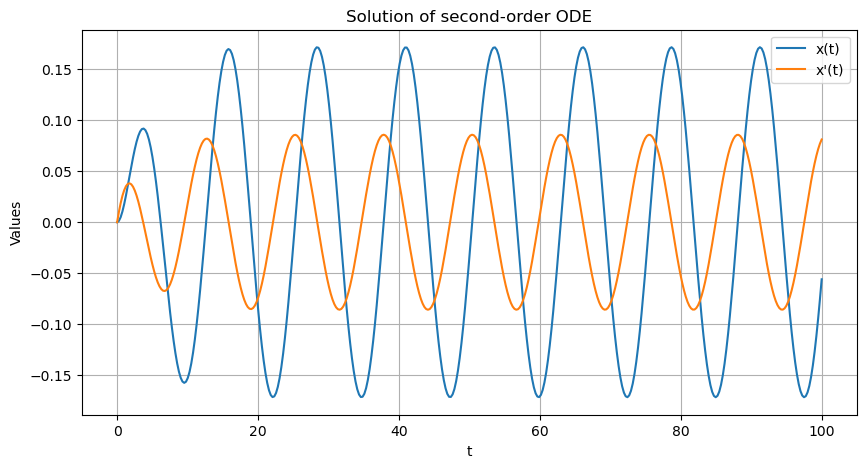

In [89]:
solution = solve_ivp(f, (0, 100), [0, 0], method = "RK45", t_eval=t_eval)

t = solution.t 
x1 = solution.y[0] # position 
x2= solution.y[1] # velocity 

plt.figure(figsize=(10,5)) 
plt.plot(t, x1, label="x(t)") 
plt.plot(t, x2, label="x'(t)") 
plt.xlabel("t") 
plt.ylabel("Values") 
plt.legend() 
plt.title("Solution of second-order ODE")
plt.grid(True) 
plt.show()

#### Phase Portrait

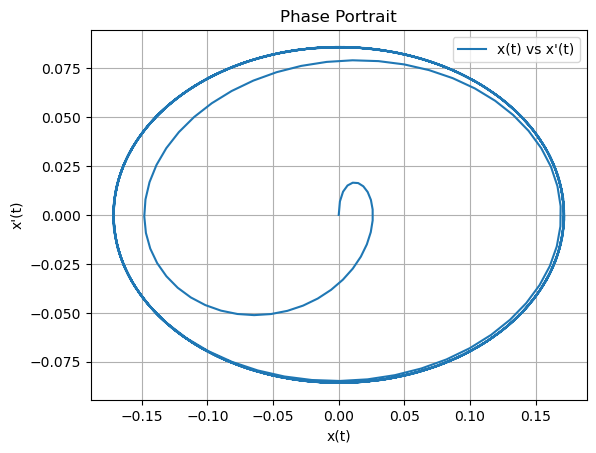

In [67]:
plt.plot(x1, x2, label="x(t) vs x'(t)") 
plt.xlabel("x(t)") 
plt.ylabel("x'(t)") 
plt.legend() 
plt.title("Phase Portrait")
plt.grid(True) 
plt.show()

#### Phase Space Vector Field 

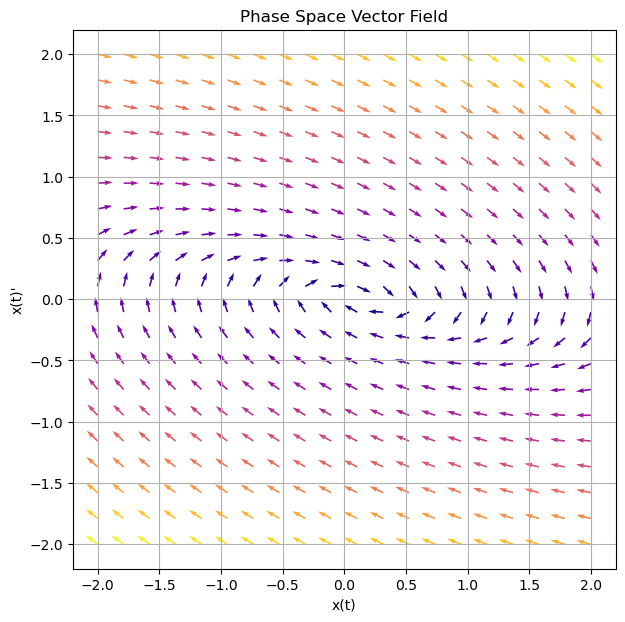

In [68]:
# Create grid in phase space
x1_vals = np.linspace(-2, 2, 20)
x2_vals = np.linspace(-2, 2, 20)
x1, x2 = np.meshgrid(x1_vals, x2_vals)

# Compute derivatives at t=0 (snapshot of vector field)
dxdt= x2
dx2dt = -w**2 * x1 - G * x2 + (e/m) * np.sqrt((h*w)/(Eo * V)) * np.cos(O)

# Normalize arrows for better visualization
norm = np.sqrt(dxdt**2 + dx2dt**2)
dxdt = dxdt / norm
dx2dt = dx2dt / norm

# Plot vector field
plt.figure(figsize=(7,7))
plt.quiver(x1, x2, dxdt, dx2dt, norm, cmap="plasma")
plt.xlabel("x(t)")
plt.ylabel("x(t)'")
plt.title("Phase Space Vector Field")
plt.grid(True)
plt.show()


## 2. Mode 2 

\begin{equation}
\frac{d^2x}{dt^2} = -\omega ^2 x - \gamma \frac{dx}{dt} + h\omega \cos (\omega t) + \theta
\end{equation}


C:\Users\julio\AppData\Local\Temp\ipykernel_27892\3738719609.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


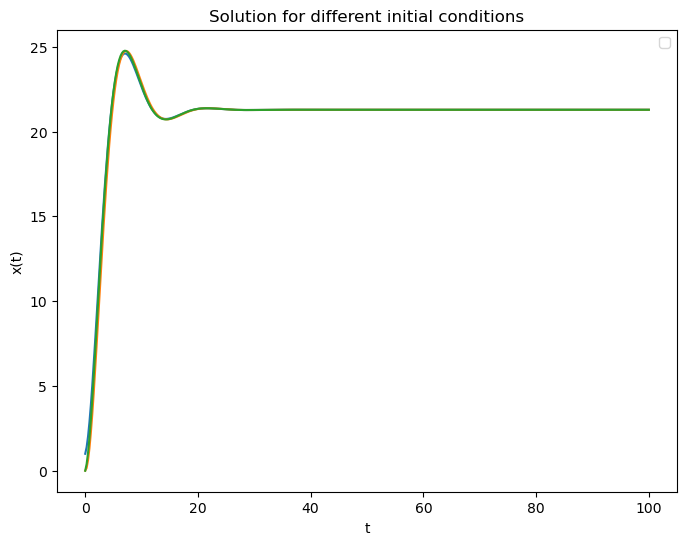

In [90]:
# Parameters
w = 0.5        #Omega
G = 0.5          #Gama
e = 1.759 * 10**11
m = 1
h = 6.626 * 10**(-34) / (2*np.pi)   # ħ
V = 100
Eo = 8.85 * 10**(-12)
O = np.random.uniform(0, 2*np.pi)


#Definition of differential Equation 
def g(t, x):
    x1, x2 = x      
    dx1dt = x2
    dx2dt = -w**2 *x1 - G* x2 +h*w* np.cos(w*t) + O
    return [dx1dt, dx2dt]  

# t interval
t_eval = np.linspace(0, 100, 400) 


#Initial Conditions 
Initial_condition = [[1, 1], [0, 0], [0, 1]]

plt.figure(figsize=(8,6))
for ic in Initial_condition:
    sol = solve_ivp(g, (0, 100), ic, method = "RK45", t_eval=t_eval)
    plt.plot(sol.t, sol.y[0])

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution for different initial conditions")
plt.legend()
plt.show()


#### Solution of Model 2

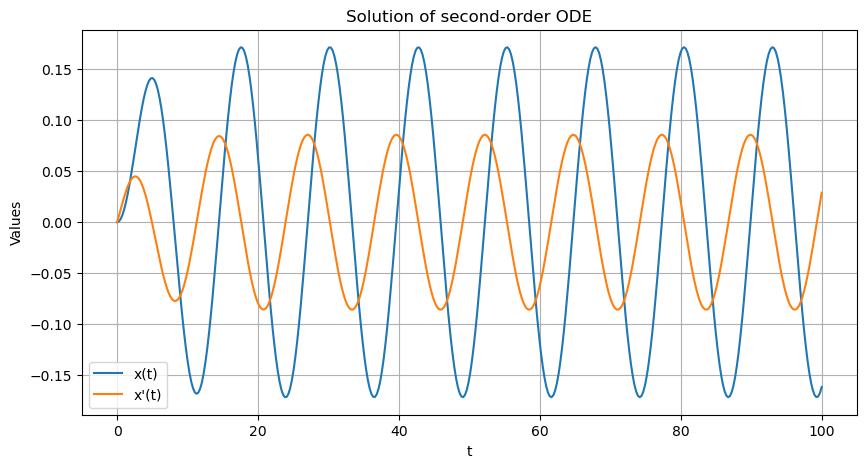

In [91]:
solution = solve_ivp(f, (0, 100), [0, 0], method = "RK45", t_eval=t_eval)

t = solution.t 
X1 = solution.y[0] # position 
X2= solution.y[1] # velocity 

plt.figure(figsize=(10,5)) 
plt.plot(t, X1, label="x(t)") 
plt.plot(t, X2, label="x'(t)") 
plt.xlabel("t") 
plt.ylabel("Values") 
plt.legend() 
plt.title("Solution of second-order ODE")
plt.grid(True) 
plt.show()

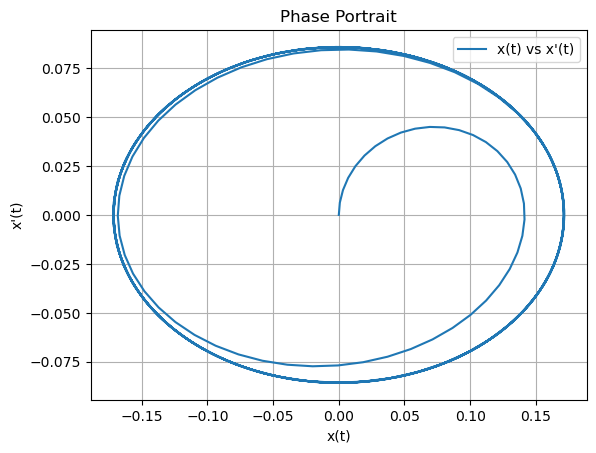

In [92]:
plt.plot(X1, X2, label="x(t) vs x'(t)") 
plt.xlabel("x(t)") 
plt.ylabel("x'(t)") 
plt.legend() 
plt.title("Phase Portrait")
plt.grid(True) 
plt.show()

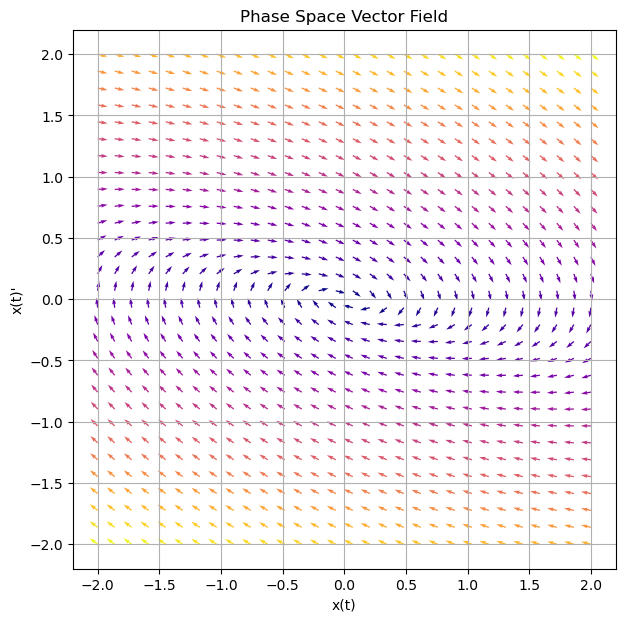

In [93]:
# Create grid in phase space
x1_vals = np.linspace(-2, 2, 30)
x2_vals = np.linspace(-2, 2, 30)
x1, x2 = np.meshgrid(x1_vals, x2_vals)

# Compute derivatives at t=0 (snapshot of vector field)
dxdt= x2
dx2dt = -w**2 * x1 - G * x2 + h*w * np.cos(O)

# Normalize arrows for better visualization
norm = np.sqrt(dxdt**2 + dx2dt**2)
dxdt = dxdt / norm
dx2dt = dx2dt / norm

# Plot vector field
plt.figure(figsize=(7,7))
plt.quiver(x1, x2, dxdt, dx2dt, norm, cmap="plasma")
plt.xlabel("x(t)")
plt.ylabel("x(t)'")
plt.title("Phase Space Vector Field")
plt.grid(True)
plt.show()

## 3. Model 3
\begin{equation}
\frac{d^2x}{dt^2} = -\omega ^2 x - \gamma \frac{dx}{dt} + h\omega \cos (\omega t) + \theta
\end{equation}


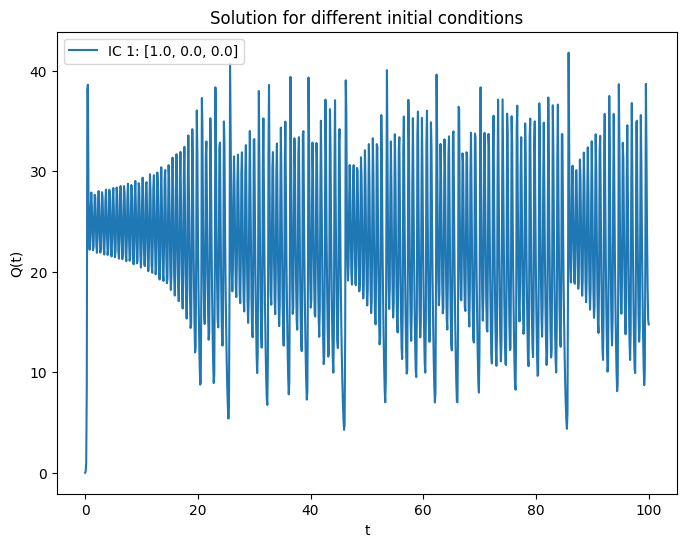

In [9]:
def g(t, x):
    u, v, Q = x      
    dudt = 10*(-u + v)
    dvdt = -v + (26 - Q)*u
    DQdt = -8/3 *Q + u*v
    return [dudt, dvdt, DQdt]  

# Initial conditions (list of different states)
Initial_condition = [
    [1.0, 0.0, 0.0]]
# Time evaluation points
t_eval = np.linspace(0, 100, 1000)

# Plot solutions
plt.figure(figsize=(8,6))
for idx, ic in enumerate(Initial_condition):
    solution = solve_ivp(g, (0, 100), ic, method="RK45", t_eval=t_eval)
    plt.plot(solution.t, solution.y[2], label=f"IC {idx+1}: {ic}")

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Solution for different initial conditions")
plt.legend()
plt.show()



# Lorenz System 
\[
\begin{aligned}
\dot{u} & = \sigma  (v - u)\\
\dot{v} & = x(r - \phi) - y\\
\dot{\phi} & = u \cdot v - b * \phi 
\end{aligned}
\]

Where:
\[
\begin{aligned}
\sigma &= 10\\
r &= 28 \\
b &= \frac{8}{3}
\end{aligned}    
\]

**Let $\phi = Z$**, because $\phi$ is not available in python directory

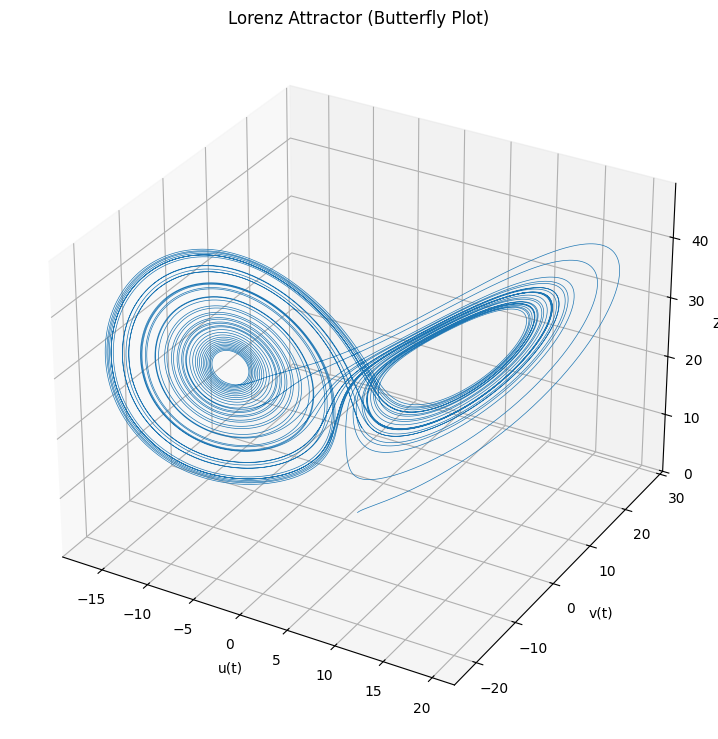

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Lorenz parameters
sigma = 10
r = 28
b = 8 / 3

# Lorenz system
def Lorenz(t, X):
    u, v, Z = X
    dudt = sigma * (v - u)
    dvdt = u * (r - Z) - v
    dZdt = u * v - b * Z
    return [dudt, dvdt, dZdt]

# Initial condition
initial_condition = [1.0, 1.0, 1.0]

# Time
t_eval = np.linspace(0, 50, 100000)

# Solve The ODE using solve_ivp
Solution = solve_ivp(Lorenz, (0, 50), initial_condition, t_eval=t_eval)

# Extract solution
u, v, Z = Solution.y


# 3D plot 
fig = plt.figure(figsize=(9,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(u, v, Z, lw=0.5)
ax.set_xlabel("u(t)")
ax.set_ylabel("v(t)")
ax.set_zlabel("Z(t)")
ax.set_title("Lorenz Attractor (Butterfly Plot)")
plt.show()


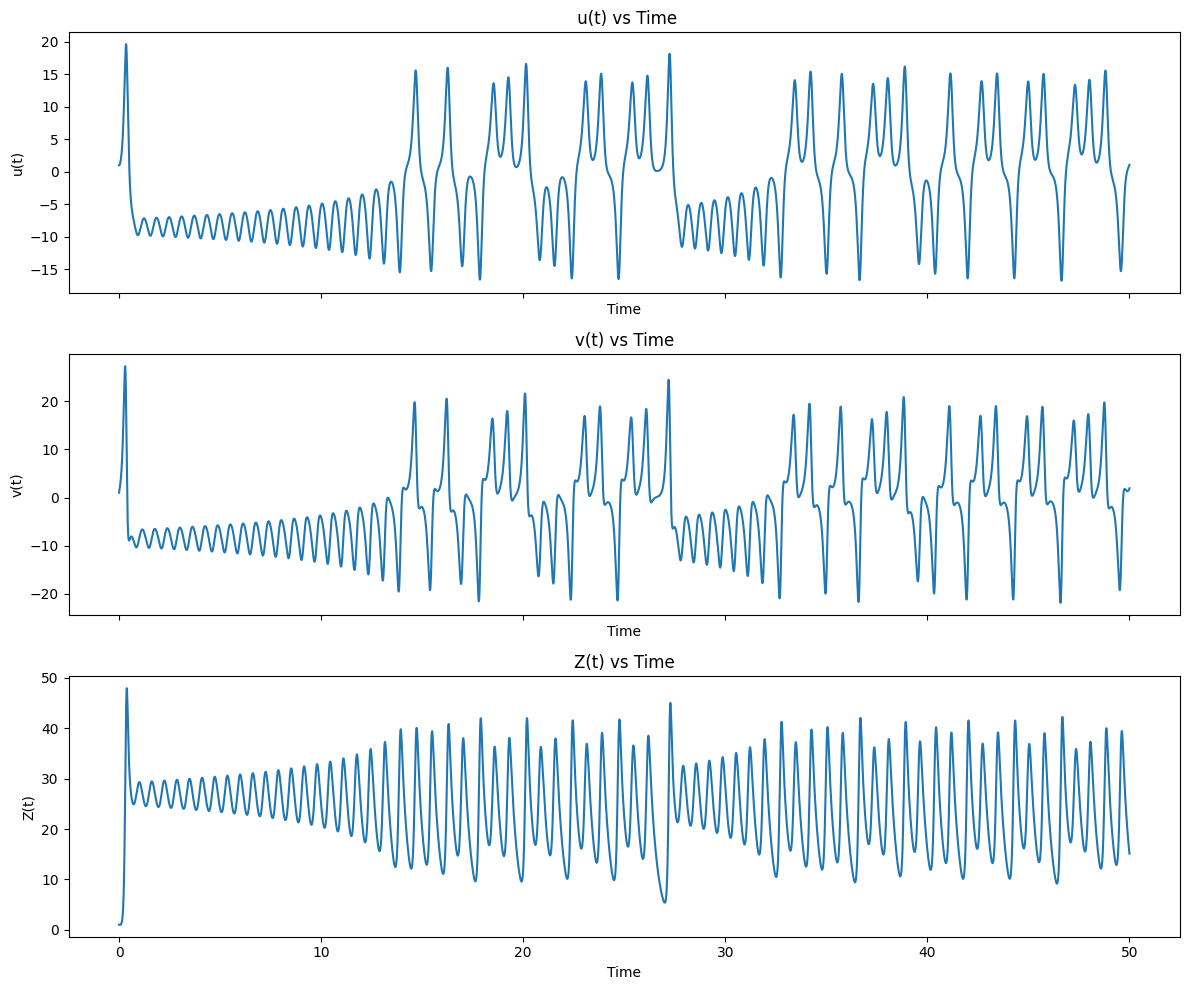

In [52]:
# Plotting u(t), v(t) and Z(t) with respect to time

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(t_eval, u)
axs[0].set_title(" u(t) vs Time")
axs[0].set_ylabel("u(t)")
axs[0].set_xlabel("Time")

axs[1].plot(t_eval, v)
axs[1].set_title("v(t) vs Time")
axs[1].set_ylabel("v(t)")   
axs[1].set_xlabel("Time")

axs[2].plot(t_eval, Z)
axs[2].set_title("Z(t) vs Time")        
axs[2].set_ylabel("Z(t)")
axs[2].set_xlabel("Time")


plt.tight_layout()
plt.show()

Autocorrelation checks how a time series relates to itself at different lags (shifts in time).
For example, lag 1 compares today’s value with yesterday’s, lag 2 compares today’s with two days ago, and so on.

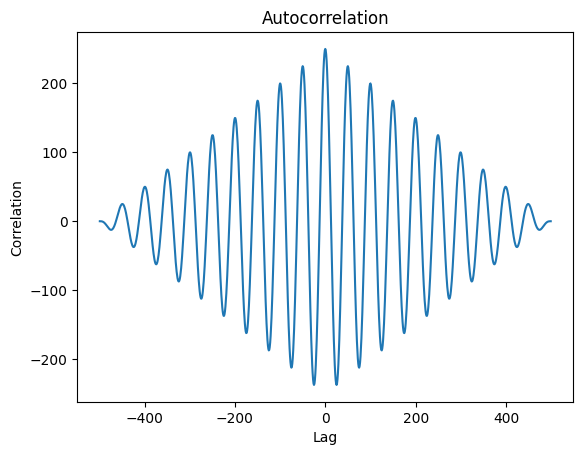

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Example signal
t = np.linspace(0, 10, 500)
signal = np.sin(2*np.pi*1*t) 

# Autocorrelation
autocorr = np.correlate(signal, signal, mode='full')
lags = np.arange(-len(signal)+1, len(signal))

plt.plot(lags, autocorr)
plt.title("Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()


In [30]:
autocorr = autocorr / autocorr[len(signal)-1]
lag1_corr = autocorr[len(signal)] # index for lag=1 
print("Correlation coefficient at lag 1:", lag1_corr)

Correlation coefficient at lag 1: 0.992083107052534


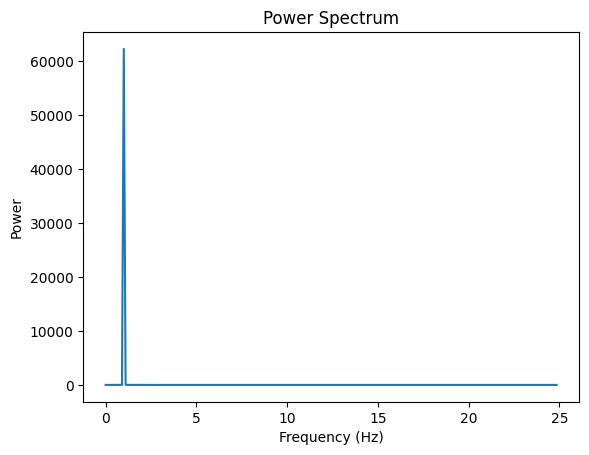

In [31]:
# Fourier transform
fft_vals = np.fft.fft(signal)
power_spectrum = np.abs(fft_vals)**2
freqs = np.fft.fftfreq(len(signal), d=t[1]-t[0])

plt.plot(freqs[:len(freqs)//2], power_spectrum[:len(freqs)//2])
plt.title("Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()


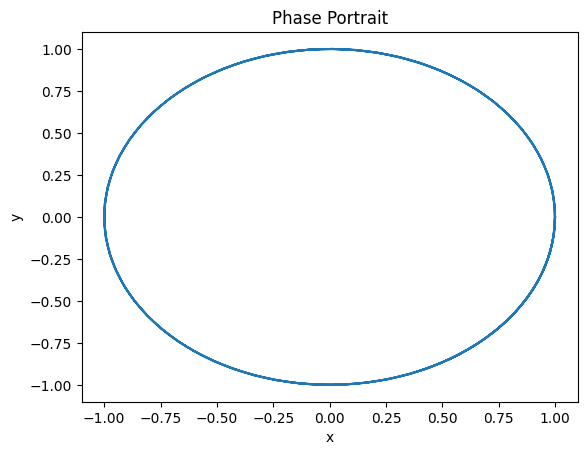

In [32]:
import numpy as np 
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt

def system(t, z):
    x, y = z
    dxdt = y
    dydt = -x
    return [dxdt, dydt]

# Solve with initial condition
sol = solve_ivp(system, (0, 20), [1, 0], t_eval=np.linspace(0, 20, 200))

# Phase portrait
plt.plot(sol.y[0], sol.y[1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase Portrait")
plt.show()


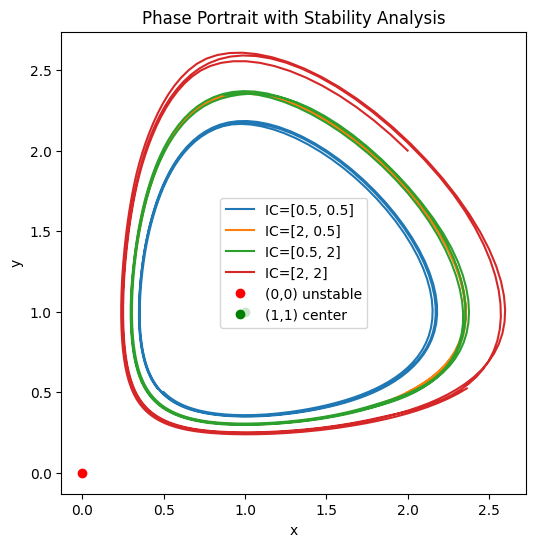

In [33]:
def system(t, z):
    x, y = z 
    dxdt = x * (1 - y) 
    dydt = y * (x - 1) 
    return [dxdt, dydt]

t_eval = np.linspace(0, 20, 400)

# Initial conditions
ics = [[0.5, 0.5], [2, 0.5], [0.5, 2], [2, 2]]

plt.figure(figsize=(6,6))
for ic in ics:
    sol = solve_ivp(system, (0, 20), ic, t_eval=t_eval)
    plt.plot(sol.y[0], sol.y[1], label=f"IC={ic}")

# Mark equilibria
plt.plot(0,0,'ro',label="(0,0) unstable")
plt.plot(1,1,'go',label="(1,1) center")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase Portrait with Stability Analysis")
plt.legend()
plt.show()

In [25]:
"""data_download.py
Scaffold for dataset preparation. Does NOT automatically perform heavy downloads without confirmation.
Edit and run sections as needed.
"""
import os
import requests

RAW_DIR = os.path.join('data','raw')
os.makedirs(RAW_DIR, exist_ok=True)

IBTRACS_URL = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv'
ibtracs_path = os.path.join(RAW_DIR, 'ibtracs.ALL.list.v04r01.csv')

def download_ibtracs(force=False):
    if os.path.exists(ibtracs_path) and not force:
        print('IBTrACS already exists at', ibtracs_path)
        return
    print('Downloading IBTrACS (approx 200 MB). Press Ctrl+C to cancel.')
    r = requests.get(IBTRACS_URL, stream=True)
    r.raise_for_status()
    with open(ibtracs_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Downloaded IBTrACS to', ibtracs_path)

if __name__ == '__main__':
    print('Scaffold: to actually download IBTrACS, call download_ibtracs()')
    # Uncomment to download:
download_ibtracs()

Scaffold: to actually download IBTrACS, call download_ibtracs()
Downloaded IBTrACS to data\raw\ibtracs.ALL.list.v04r01.csv


In [26]:
"""evaluate.py
Evaluate predicted vs. observed tracks (haversine distance) and simple impact metrics.
"""
import pandas as pd
import os
from math import radians, sin, cos, asin, sqrt

obs_path = os.path.join('data','processed','observed_tracks_moz.csv')  # user-provided
pred_path = os.path.join('predictions','predicted_tracks.csv')

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return 6371 * c

if not os.path.exists(obs_path):
    print('Place observed tracks CSV at', obs_path, 'with columns: storm_id,time,lat,lon')
elif not os.path.exists(pred_path):
    print('Place predicted tracks CSV at', pred_path, 'with columns: storm_id,time,lat,lon')
else:
    obs = pd.read_csv(obs_path)
    pred = pd.read_csv(pred_path)
    merged = pd.merge(obs, pred, on=['storm_id','time'], suffixes=('_obs','_pred'))
    merged['haversine_km'] = merged.apply(lambda r: haversine(r['lon_obs'], r['lat_obs'], r['lon_pred'], r['lat_pred']), axis=1)
    print('Mean track error (km):', merged['haversine_km'].mean())


C:\Users\julio\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Place observed tracks CSV at data\processed\observed_tracks_moz.csv with columns: storm_id,time,lat,lon
